# Ridge And Lasso Logistic Regression

This notebook trains and compares ridge logistic regression and lasso logistic regression on the Tommy Award same-game dataset.

It uses the top same-game feature set from `Same_Game_And_Pregame_Logistic_Experiments.ipynb` so the notebook matches the feature style you have already been using.

In [4]:
# Import the libraries used for loading data, preprocessing,
# model training, evaluation, and coefficient inspection.
import warnings
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", message=".*penalty.*deprecated.*", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*penalty=l1.*", category=UserWarning)

# Basic configuration shared across the notebook.
INPUT_PATH = "Tommy_Award_Player_Game_Table_hustle.csv"
RANDOM_STATE = 42
MIN_TRAIN_SEASONS = 3
TEST_SEASONS = ["2023-24", "2024-25", "2025-26"]
PRED_THRESHOLD = 0.5
ELASTICNET_L1_RATIO = 0.5

In [5]:
# Load the dataset, recreate any missing derived same-game features,
# and define the shared feature list from Same_Game_And_Pregame_Logistic_Experiments.ipynb.
def load_dataset(path: str = INPUT_PATH) -> pd.DataFrame:
    df = pd.read_csv(path, dtype={"GAME_ID": str}).copy()
    df["game_date"] = pd.to_datetime(df["game_date"], format="mixed")

    # Keep only players who actually played in the game.
    df = df[df["minutes_decimal"] > 0].copy()

    mins = df["minutes_decimal"].clip(lower=1e-6)
    if "stocks" not in df.columns:
        df["stocks"] = df["steals"] + df["blocks"]
    if "points_per_min" not in df.columns:
        df["points_per_min"] = df["points"] / mins
    if "oreb_per_min" not in df.columns:
        df["oreb_per_min"] = df["reboundsOffensive"] / mins
    if "reb_per_min" not in df.columns:
        df["reb_per_min"] = df["reboundsTotal"] / mins
    if "ast_per_min" not in df.columns:
        df["ast_per_min"] = df["assists"] / mins
    if "deflections" not in df.columns:
        if "DEFLECTIONS" in df.columns:
            df["deflections"] = df["DEFLECTIONS"]
        else:
            df["deflections"] = 0.0

    if "charges_drawn" not in df.columns:
        if "chargesDrawn" in df.columns:
            df["charges_drawn"] = df["chargesDrawn"]
        elif "CHARGES_DRAWN" in df.columns:
            df["charges_drawn"] = df["CHARGES_DRAWN"]
        else:
            df["charges_drawn"] = 0.0

    # Define hustle proxy as per-minute hustle actions.
    df["hustle_proxy"] = (df["reboundsOffensive"] + df["steals"] + df["blocks"]) / mins
    if "stocks_per_min" not in df.columns:
        df["stocks_per_min"] = df["stocks"] / mins

    # Build net_rating and usage_rate with fallbacks when raw fields are missing.
    if "net_rating" in df.columns:
        df["net_rating"] = pd.to_numeric(df["net_rating"], errors="coerce")
    elif "Net_Rating" in df.columns:
        df["net_rating"] = pd.to_numeric(df["Net_Rating"], errors="coerce")
    elif "NET_RATING" in df.columns:
        df["net_rating"] = pd.to_numeric(df["NET_RATING"], errors="coerce")
    else:
        # Fallback proxy when no explicit net rating is available.
        df["net_rating"] = pd.to_numeric(df["plusMinusPoints"], errors="coerce")

    if "usage_rate" in df.columns:
        df["usage_rate"] = pd.to_numeric(df["usage_rate"], errors="coerce")
    elif "Usage_Rate" in df.columns:
        df["usage_rate"] = pd.to_numeric(df["Usage_Rate"], errors="coerce")
    elif "USG_PCT" in df.columns:
        df["usage_rate"] = pd.to_numeric(df["USG_PCT"], errors="coerce") / 100.0
    else:
        # Proxy usage share within each game if explicit usage rate is absent.
        usage_numerator = (
            pd.to_numeric(df["fieldGoalsAttempted"], errors="coerce").fillna(0)
            + 0.44 * pd.to_numeric(df["freeThrowsAttempted"], errors="coerce").fillna(0)
            + pd.to_numeric(df["turnovers"], errors="coerce").fillna(0)
        )
        usage_denom = usage_numerator.groupby(df["GAME_ID"]).transform("sum")
        df["usage_rate"] = (usage_numerator / usage_denom.replace(0, np.nan)).fillna(0.0)

    df["usage_rate"] = df["usage_rate"].clip(lower=0, upper=1)
    eps = 1e-6
    df["impact_efficiency"] = df["net_rating"] / (df["usage_rate"] + eps)
    df["role_outperformance"] = df["net_rating"] * (1 - df["usage_rate"])

    rank_sources = {
        "points_rank": "points",
        "reboundsOffensive_rank": "reboundsOffensive",
        "reboundsTotal_rank": "reboundsTotal",
        "assists_rank": "assists",
        "steals_rank": "steals",
        "blocks_rank": "blocks",
        "plusMinusPoints_rank": "plusMinusPoints",
        "minutes_decimal_rank": "minutes_decimal",
        "stocks_rank": "stocks",
        "hustle_proxy_rank": "hustle_proxy",
    }
    for rank_col, source_col in rank_sources.items():
        if rank_col not in df.columns:
            df[rank_col] = df.groupby("GAME_ID")[source_col].rank(method="min", ascending=False)

    if "season" not in df.columns:
        start_year = df["game_date"].dt.year.where(df["game_date"].dt.month >= 10, df["game_date"].dt.year - 1)
        df["season"] = start_year.astype(str) + "-" + (start_year + 1).astype(str).str[-2:]

    return df


def sorted_seasons(seasons: list[str]) -> list[str]:
    return sorted(seasons, key=lambda season: int(str(season).split("-")[0]))


def get_feature_columns(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    numeric_cols = [
        "minutes_decimal",
        "points",
        "reboundsOffensive",
        "reboundsDefensive",
        "reboundsTotal",
        "assists",
        "steals",
        "blocks",
        "deflections",
        "charges_drawn",
        "turnovers",
        "foulsPersonal",
        "plusMinusPoints",
        "net_rating",
        "usage_rate",
        "impact_efficiency",
        "role_outperformance",
        "fieldGoalsMade",
        "fieldGoalsAttempted",
        "threePointersMade",
        "threePointersAttempted",
        "freeThrowsMade",
        "stocks",
        "points_per_min",
        "oreb_per_min",
        "reb_per_min",
        "ast_per_min",
        "stocks_per_min",
        "hustle_proxy",
        "points_rank",
        "reboundsOffensive_rank",
        "reboundsTotal_rank",
        "assists_rank",
        "steals_rank",
        "blocks_rank",
        "plusMinusPoints_rank",
        "minutes_decimal_rank",
        "stocks_rank",
        "hustle_proxy_rank",
    ]

    missing_cols = [col for col in numeric_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing feature columns: {missing_cols}")

    return numeric_cols, []


def latest_season_holdout_split(
    df: pd.DataFrame,
    test_seasons: list[str] = TEST_SEASONS,
) -> tuple[pd.DataFrame, pd.DataFrame, list[str]]:
    seasons = sorted_seasons(df["season"].dropna().unique().tolist())
    selected_test_seasons = [season for season in test_seasons if season in seasons]
    if not selected_test_seasons:
        raise ValueError(
            f"None of the requested test seasons were found. Requested={test_seasons}, available={seasons}"
        )

    train_df = df[~df["season"].isin(selected_test_seasons)].copy()
    test_df = df[df["season"].isin(selected_test_seasons)].copy()
    return train_df, test_df, selected_test_seasons

In [6]:
# Build the numeric preprocessing and the two logistic regression models.
def build_preprocessor(numeric_cols: list[str], categorical_cols: list[str]) -> ColumnTransformer:
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
        ]
    )


def build_ridge_pipeline(numeric_cols: list[str], categorical_cols: list[str]) -> Pipeline:
    return Pipeline(
        steps=[
            ("prep", build_preprocessor(numeric_cols, categorical_cols)),
            (
                "clf",
                LogisticRegression(
                    penalty="l2",
                    C=1.0,
                    solver="lbfgs",
                    max_iter=5000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


def build_lasso_pipeline(numeric_cols: list[str], categorical_cols: list[str]) -> Pipeline:
    return Pipeline(
        steps=[
            ("prep", build_preprocessor(numeric_cols, categorical_cols)),
            (
                "clf",
                LogisticRegression(
                    penalty="l1",
                    C=1.0,
                    solver="liblinear",
                    max_iter=5000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


def build_elasticnet_pipeline(numeric_cols: list[str], categorical_cols: list[str]) -> Pipeline:
    return Pipeline(
        steps=[
            ("prep", build_preprocessor(numeric_cols, categorical_cols)),
            (
                "clf",
                LogisticRegression(
                    penalty="elasticnet",
                    l1_ratio=ELASTICNET_L1_RATIO,
                    C=1.0,
                    solver="saga",
                    max_iter=10000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


def available_model_names() -> list[str]:
    return ["ridge_logistic", "lasso_logistic", "elasticnet_logistic"]

In [7]:
# Score predictions using the same game-level and row-level metrics
# used in your other modeling notebooks.
def score_predictions(scored_df: pd.DataFrame) -> dict[str, float]:
    y_true = scored_df["y"].astype(int)
    y_prob = scored_df["pred_prob"].clip(1e-6, 1 - 1e-6)

    # Rank-1 logic: exactly one predicted winner per game.
    winner_idx = scored_df.groupby("GAME_ID")["pred_prob"].idxmax()
    y_pred = pd.Series(0, index=scored_df.index, dtype=int)
    y_pred.loc[winner_idx] = 1

    return {
        "game_top1_accuracy": scored_df.loc[winner_idx, "y"].mean(),
        "row_f1": f1_score(y_true, y_pred, zero_division=0),
        "row_recall": recall_score(y_true, y_pred, zero_division=0),
        "row_prauc": average_precision_score(y_true, y_prob),
        "row_precision": precision_score(y_true, y_pred, zero_division=0),
    }


def fit_and_score_model(
    model_name: str,
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    numeric_cols: list[str],
    categorical_cols: list[str],
) -> tuple[Pipeline, pd.DataFrame, dict[str, float]]:
    feature_cols = numeric_cols + categorical_cols
    X_train = train_df[feature_cols]
    X_test = test_df[feature_cols]
    y_train = train_df["y"]

    if model_name == "ridge_logistic":
        model = build_ridge_pipeline(numeric_cols, categorical_cols)
    elif model_name == "lasso_logistic":
        model = build_lasso_pipeline(numeric_cols, categorical_cols)
    elif model_name == "elasticnet_logistic":
        model = build_elasticnet_pipeline(numeric_cols, categorical_cols)
    else:
        raise ValueError(f"Unsupported model_name: {model_name}")

    model.fit(X_train, y_train)

    scored_df = test_df.copy()
    scored_df["pred_prob"] = model.predict_proba(X_test)[:, 1]
    metrics = score_predictions(scored_df)
    return model, scored_df, metrics


def rank_results(results_df: pd.DataFrame) -> pd.DataFrame:
    ranked_df = results_df.sort_values(
        by=[
            "game_top1_accuracy",
            "row_f1",
            "row_recall",
            "row_prauc",
            "row_precision",
        ],
        ascending=[False, False, False, False, False],
    ).reset_index(drop=True)
    ranked_df.insert(0, "rank", range(1, len(ranked_df) + 1))
    return ranked_df

In [8]:
# Load the data, inspect the shared feature set, and summarize the modeling setup.
df = load_dataset()
numeric_cols, categorical_cols = get_feature_columns(df)
model_names = available_model_names()
train_df, latest_test_df, selected_test_seasons = latest_season_holdout_split(df)

summary_df = pd.DataFrame(
    {
        "item": [
            "rows",
            "numeric_features",
            "categorical_features",
            "train_games",
            "test_games",
            "train_positive_rate",
            "test_seasons",
            "models",
        ],
        "value": [
            len(df),
            len(numeric_cols),
            len(categorical_cols),
            train_df["GAME_ID"].nunique(),
            latest_test_df["GAME_ID"].nunique(),
            round(train_df["y"].mean(), 4),
            ", ".join(selected_test_seasons),
            ", ".join(model_names),
        ],
    }
)

display(summary_df)

,item,value
0,rows,8495
1,numeric_features,39
2,categorical_features,0
3,train_games,547
4,test_games,242
5,train_positive_rate,0.0922
6,test_seasons,"2023-24, 2024-25, 2025-26"
7,models,"ridge_logistic, lasso_logistic, elasticnet_log..."


In [6]:
# Walk-forward evaluation removed.
# This notebook now uses a fixed season split:
# - train: all seasons except TEST_SEASONS
# - test: seasons in TEST_SEASONS
pass

,model,test_season,game_top1_accuracy,row_f1,row_recall,row_prauc,row_precision
0,ridge_logistic,2019-20,0.4861,0.4861,0.4861,0.4659,0.4861
1,lasso_logistic,2019-20,0.5000,0.5000,0.5000,0.4662,0.5000
2,elasticnet_logistic,2019-20,0.4861,0.4861,0.4861,0.4668,0.4861
3,ridge_logistic,2020-21,0.2083,0.2083,0.2083,0.2267,0.2083
4,lasso_logistic,2020-21,0.2083,0.2083,0.2083,0.2267,0.2083
5,elasticnet_logistic,2020-21,0.2083,0.2083,0.2083,0.2266,0.2083
6,ridge_logistic,2021-22,0.3500,0.3500,0.3500,0.3145,0.3500
7,lasso_logistic,2021-22,0.3500,0.3500,0.3500,0.3137,0.3500
8,elasticnet_logistic,2021-22,0.3500,0.3500,0.3500,0.3144,0.3500
9,ridge_logistic,2022-23,0.2195,0.2195,0.2195,0.2347,0.2195


,rank,model,game_top1_accuracy,row_f1,row_recall,row_prauc,row_precision
0,1,lasso_logistic,0.3251,0.3251,0.3251,0.3238,0.3251
1,2,ridge_logistic,0.3231,0.3231,0.3231,0.3238,0.3231
2,3,elasticnet_logistic,0.3231,0.3231,0.3231,0.3238,0.3231


In [9]:
# Train each model on non-test seasons and evaluate on the selected test seasons.
latest_rows = []
trained_models = {}
latest_scored_outputs = {}

test_season_label = ", ".join(selected_test_seasons)

for model_name in model_names:
    model, scored_df, metrics = fit_and_score_model(
        model_name,
        train_df,
        latest_test_df,
        numeric_cols,
        categorical_cols,
    )
    trained_models[model_name] = model
    latest_scored_outputs[model_name] = scored_df
    latest_rows.append({"model": model_name, "test_seasons": test_season_label, **metrics})

latest_results_df = pd.DataFrame(latest_rows)
latest_ranked_df = rank_results(latest_results_df)

display(latest_ranked_df.round(4))

,rank,model,test_seasons,game_top1_accuracy,row_f1,row_recall,row_prauc,row_precision
0,1,lasso_logistic,"2023-24, 2024-25, 2025-26",0.3223,0.3223,0.3223,0.3173,0.3223
1,2,elasticnet_logistic,"2023-24, 2024-25, 2025-26",0.3223,0.3223,0.3223,0.3173,0.3223
2,3,ridge_logistic,"2023-24, 2024-25, 2025-26",0.3223,0.3223,0.3223,0.3171,0.3223


In [10]:
# Inspect the largest coefficients from each trained model.
# Ridge keeps all coefficients, while lasso may push some exactly to zero.
coefficient_tables = {}

for model_name, pipeline in trained_models.items():
    log_model = pipeline.named_steps["clf"]
    coef_df = pd.DataFrame(
        {
            "feature": numeric_cols,
            "coefficient": log_model.coef_[0],
        }
    )
    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
    coef_df = coef_df.sort_values("abs_coefficient", ascending=False)
    coefficient_tables[model_name] = coef_df

    print(f"\nTop coefficients: {model_name}")
    display(coef_df.head(20).round(4))


Top coefficients: ridge_logistic


,feature,coefficient,abs_coefficient
18,fieldGoalsAttempted,-1.6395,1.6395
29,points_rank,-1.2771,1.2771
22,stocks,1.0732,1.0732
17,fieldGoalsMade,0.8900,0.8900
6,steals,-0.6505,0.6505
7,blocks,-0.6360,0.6360
0,minutes_decimal,0.5752,0.5752
1,points,0.5664,0.5664
25,reb_per_min,0.4188,0.4188
23,points_per_min,0.4016,0.4016



Top coefficients: lasso_logistic


,feature,coefficient,abs_coefficient
18,fieldGoalsAttempted,-1.6365,1.6365
17,fieldGoalsMade,1.3091,1.3091
29,points_rank,-1.2715,1.2715
22,stocks,0.6454,0.6454
0,minutes_decimal,0.5509,0.5509
25,reb_per_min,0.4017,0.4017
2,reboundsOffensive,0.3926,0.3926
23,points_per_min,0.3906,0.3906
35,plusMinusPoints_rank,-0.3759,0.3759
20,threePointersAttempted,0.3729,0.3729



Top coefficients: elasticnet_logistic


,feature,coefficient,abs_coefficient
18,fieldGoalsAttempted,-1.6354,1.6354
29,points_rank,-1.2747,1.2747
17,fieldGoalsMade,1.1132,1.1132
22,stocks,0.9189,0.9189
0,minutes_decimal,0.5690,0.5690
7,blocks,-0.5370,0.5370
6,steals,-0.5352,0.5352
25,reb_per_min,0.4114,0.4114
23,points_per_min,0.4016,0.4016
2,reboundsOffensive,0.3971,0.3971


In [11]:
# Show the full shared feature set used by both models.
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)

print("Numeric features")
display(pd.DataFrame({"numeric_feature": numeric_cols}))

print("Categorical features")
display(pd.DataFrame({"categorical_feature": categorical_cols}))

Numeric features


,numeric_feature
0,minutes_decimal
1,points
2,reboundsOffensive
3,reboundsDefensive
4,reboundsTotal
5,assists
6,steals
7,blocks
8,deflections
9,charges_drawn


Categorical features


,categorical_feature


Model for confusion matrix: lasso_logistic
Evaluation split: 2023-24, 2024-25, 2025-26
Prediction rule: rank-1 winner per game (argmax pred_prob)
TP=78, FP=164, FN=164, TN=2157


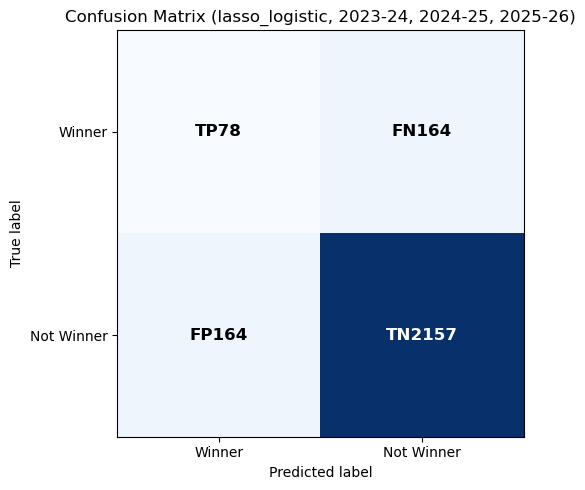

In [12]:
# Confusion matrix for the top-ranked model on the selected test seasons.
# Uses class order [Winner=1, Not Winner=0] so layout is:
# [[TP, FN],
#  [FP, TN]]
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

if "latest_ranked_df" not in globals() or "latest_scored_outputs" not in globals():
    raise RuntimeError("Run the model training/evaluation cells first.")

best_model_name = latest_ranked_df.iloc[0]["model"]
cm_df = latest_scored_outputs[best_model_name].copy()

y_true = cm_df["y"].astype(int)
y_prob = cm_df["pred_prob"].clip(1e-6, 1 - 1e-6)

# Rank-1 logic: one predicted winner per GAME_ID.
winner_idx = cm_df.groupby("GAME_ID")["pred_prob"].idxmax()
y_pred = pd.Series(0, index=cm_df.index, dtype=int)
y_pred.loc[winner_idx] = 1

cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
tp, fn, fp, tn = cm.ravel()

test_season_label = ", ".join(selected_test_seasons) if "selected_test_seasons" in globals() else "selected test seasons"
print(f"Model for confusion matrix: {best_model_name}")
print(f"Evaluation split: {test_season_label}")
print("Prediction rule: rank-1 winner per game (argmax pred_prob)")
print(f"TP={tp}, FP={fp}, FN={fn}, TN={tn}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Winner", "Not Winner"]).plot(
    ax=ax,
    cmap="Blues",
    include_values=False,
    colorbar=False,
)

cell_labels = [["TP", "FN"], ["FP", "TN"]]
threshold = cm.max() / 2.0
for i in range(2):
    for j in range(2):
        value = cm[i, j]
        label = cell_labels[i][j]
        color = "white" if value > threshold else "black"
        ax.text(
            j,
            i,
            f"{label}{value}",
            ha="center",
            va="center",
            color=color,
            fontsize=12,
            fontweight="bold",
        )

ax.set_title(f"Confusion Matrix ({best_model_name}, {test_season_label})")
plt.tight_layout()
plt.show()

In [13]:
# Review individual games to see what the best latest-season model predicted.
if "latest_ranked_df" not in globals() or "latest_scored_outputs" not in globals():
    raise RuntimeError("Run the model training/evaluation cells first.")

best_model_name = latest_ranked_df.iloc[0]["model"]
review_df = latest_scored_outputs[best_model_name].copy()

winner_idx = review_df.groupby("GAME_ID")["pred_prob"].idxmax()
pred_winners = review_df.loc[winner_idx, ["GAME_ID", "game_date", "player_name", "pred_prob"]].copy()
pred_winners = pred_winners.rename(columns={
    "player_name": "predicted_winner",
    "pred_prob": "predicted_prob",
})

actual_winners = (
    review_df.loc[review_df["y"] == 1, ["GAME_ID", "game_date", "winner_names"]]
    .drop_duplicates(subset=["GAME_ID"])
    .rename(columns={"winner_names": "actual_winner"})
)

game_review_df = actual_winners.merge(pred_winners, on=["GAME_ID", "game_date"], how="left")
game_review_df["correct"] = game_review_df["actual_winner"] == game_review_df["predicted_winner"]
game_review_df = game_review_df.sort_values("game_date").reset_index(drop=True)

display(game_review_df.head(20))

print("Incorrect prediction examples:")
incorrect_games = game_review_df.loc[~game_review_df["correct"]].head(5)
for _, game in incorrect_games.iterrows():
    game_players = (
        review_df.loc[review_df["GAME_ID"] == game["GAME_ID"], ["player_name", "pred_prob", "y"]]
        .sort_values("pred_prob", ascending=False)
        .head(5)
        .copy()
    )
    game_players["actual_winner_flag"] = game_players["y"].map({1: "actual winner", 0: ""})

    print(f"\n{game['game_date'].date()} | GAME_ID {game['GAME_ID']}")
    print(f"Actual winner: {game['actual_winner']}")
    print(f"Predicted winner: {game['predicted_winner']} (prob={game['predicted_prob']:.4f})")
    display(game_players[["player_name", "pred_prob", "actual_winner_flag"]].reset_index(drop=True))

,GAME_ID,game_date,actual_winner,predicted_winner,predicted_prob,correct
0,22300065,2023-10-25,Kristaps Porzingis,Jayson Tatum,0.874903,False
1,22300080,2023-10-27,Derrick White,Derrick White,0.939578,True
2,22300103,2023-10-30,Kristaps Porzingis,Jaylen Brown,0.962127,False
3,22300118,2023-11-01,Payton Pritchard,Jayson Tatum,0.883237,False
4,22300136,2023-11-04,Luke Kornet,Kristaps Porziņģis,0.817527,False
5,22300154,2023-11-06,Jaylen Brown,Jayson Tatum,0.833203,False
6,22300159,2023-11-08,Jrue Holiday,Kristaps Porziņģis,0.917432,False
7,22300010,2023-11-10,Jrue Holiday,Jaylen Brown,0.809504,False
8,22300174,2023-11-11,Jaylen Brown,Jaylen Brown,0.798362,True
9,22300188,2023-11-13,Kristaps Porzingis,Jayson Tatum,0.898807,False


Incorrect prediction examples:

2023-10-25 | GAME_ID 22300065
Actual winner: Kristaps Porzingis
Predicted winner: Jayson Tatum (prob=0.8749)


,player_name,pred_prob,actual_winner_flag
0,Jayson Tatum,0.874903,
1,Kristaps Porziņģis,0.861071,actual winner
2,Derrick White,0.732458,
3,Jrue Holiday,0.291547,
4,Jaylen Brown,0.285618,



2023-10-30 | GAME_ID 22300103
Actual winner: Kristaps Porzingis
Predicted winner: Jaylen Brown (prob=0.9621)


,player_name,pred_prob,actual_winner_flag
0,Jaylen Brown,0.962127,
1,Jayson Tatum,0.890832,
2,Kristaps Porziņģis,0.737751,actual winner
3,Jrue Holiday,0.581508,
4,Al Horford,0.538998,


...

,player_name,pred_prob,actual_winner_flag
0,Jayson Tatum,0.883237,
1,Derrick White,0.837873,
2,Sam Hauser,0.739878,
3,Payton Pritchard,0.503147,actual winner
4,Jrue Holiday,0.392991,



2023-11-04 | GAME_ID 22300136
Actual winner: Luke Kornet
Predicted winner: Kristaps Porziņģis (prob=0.8175)


,player_name,pred_prob,actual_winner_flag
0,Kristaps Porziņģis,0.817527,
1,Jayson Tatum,0.761545,
2,Luke Kornet,0.683835,actual winner
3,Jrue Holiday,0.664527,
4,Al Horford,0.396446,



2023-11-06 | GAME_ID 22300154
Actual winner: Jaylen Brown
Predicted winner: Jayson Tatum (prob=0.8332)


,player_name,pred_prob,actual_winner_flag
0,Jayson Tatum,0.833203,
1,Jaylen Brown,0.581772,actual winner
2,Kristaps Porziņģis,0.413027,
3,Sam Hauser,0.375529,
4,Al Horford,0.231232,
